Exercise 12.1

Write a program that fits the events saved in the file dati.txt.
- Take care to determine the range and binning of the histogram used for the fit based on the events themselves, writing appropriate algorithms to determine the minimum and maximum of the sample and a reasonable estimate of the number of bins to use.
- Determine the initial values of the fit parameters using the techniques described in the lesson.
- Print the fit result on the screen.
- Plot the histogram with the fitted model overlaid.
- Which parameters are correlated, and which are anti-correlated with each other?

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open ('dati.txt') as input_file:
    randlist = [float (x) for x in input_file.readlines()]

In [3]:
from math import floor
mean_randlist = np.mean(randlist)
sigma_randlist = np.std(randlist)
xmin = min(randlist)
xmax = max(randlist)
x_range = (xmin, xmax)
Nbins = floor(len(randlist)/100. + 1)
bin_content, bin_edges = np.histogram( randlist, bins = Nbins, range = x_range)

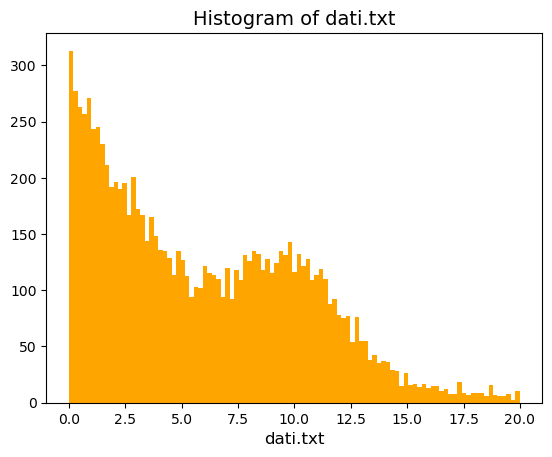

In [4]:
fig, ax = plt.subplots()
ax.hist( randlist, bins = bin_edges, color = 'orange')
ax.set_title('Histogram of dati.txt', size = 14)
ax.set_xlabel('dati.txt', size = 12)
plt.show()

In [5]:
from scipy.stats import norm, expon
def mod_total (bin_edges, N_signal, mu, sigma, N_background, tau):
    return N_signal * norm.cdf (bin_edges, mu, sigma) + N_background * expon.cdf (bin_edges, 0, tau )

In [6]:
from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL
my_cost_func = ExtendedBinnedNLL ( bin_content, bin_edges, mod_total)
my_minuit = Minuit( my_cost_func, N_signal = len(randlist), mu = mean_randlist, sigma = sigma_randlist, N_background = len(randlist), tau = 1.)
my_minuit.limits['N_signal', 'N_background', 'sigma', 'tau']= (0, None)

In [7]:
my_minuit.values['N_signal'] = 0
my_minuit.fixed ['N_signal', 'mu', 'sigma'] = True
bin_centres = 0.5 * ( bin_edges[1:]  + bin_edges[:-1] )
my_cost_func.mask = (bin_centres < 5) | (bin_centres > 15)

my_minuit.migrad()
my_minuit.minos()                                                 #incertezze dei parametri prese dalla likelihood 
print('The fit is : ', my_minuit.valid)
display(my_minuit)

The fit is :  True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 39.53 (χ²/ndof = 0.8)      │              Nfcn = 139              │
│ EDM = 1.18e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name         │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_signal     │     0     │   0.1e3   │            │            │    0    │         │  yes  │
│ 1 │ mu           │   5.92    │   0.06    │            │            │         │         │  yes  │
│ 2 │ sigma        │   4.43    │   0.04    │            │            │    0    │         │  yes  │
│ 3 │ N_background │  7.97e3   │  0.13e3   │  -0.13e3   │   0.13e3   │    0    │         │       │
│ 4 │ tau          │    5.2    │    0.1    │    -0.1    │    0.1     │    0    │         │       │
└───┴──────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │     N_background      │          tau          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.13e3  │  0.13e3   │   -0.1    │    0.1    │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌──────────────┬──────────────────────────────────────────────────────────────────┐
│              │     N_signal           mu        sigma N_background          tau │
├──────────────┼──────────────────────────────────────────────────────────────────┤
│     N_signal │            0            0            0            0        0.000 │
│           mu │            0            0            0            0        0.000 │
│        sigma │            0            0            0            0        0.000 │
│ N_background │            0            0            0     1.73e+04        7.331 │
│          tau │        0.000        0.000        0.000        7.331       0.0107 │
└──────────────┴──────────────────────────────────────────────────────────────────┘

In [8]:
my_cost_func.mask = None
my_minuit.fixed = False
my_minuit.fixed['N_background', 'tau'] = True
my_minuit.values['N_signal'] = len(randlist) - my_minuit.values['N_background']

my_minuit.migrad()
my_minuit.minos()                                                 #incertezze dei parametri prese dalla likelihood 
print('The fit is : ', my_minuit.valid)
display(my_minuit)

The fit is :  True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 83.54 (χ²/ndof = 0.9)      │              Nfcn = 396              │
│ EDM = 4.3e-07 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name         │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_signal     │  2.24e3   │  0.07e3   │  -0.07e3   │   0.07e3   │    0    │         │       │
│ 1 │ mu           │   9.98    │   0.08    │   -0.08    │    0.08    │         │         │       │
│ 2 │ sigma        │   2.05    │   0.07    │   -0.06    │    0.07    │    0    │         │       │
│ 3 │ N_background │  7.97e3   │  0.13e3   │  -0.13e3   │   0.13e3   │    0    │         │  yes  │
│ 4 │ tau          │    5.2    │    0.1    │    -0.1    │    0.1     │    0    │         │  yes  │
└───┴──────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │     N_background      │          tau          │       N_signal        │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.13e3  │  0.13e3   │   -0.1    │    0.1    │    -70    │    70     │   -0.08   │   0.08    │   -0.06   │   0.07    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────────────┬──────────────────────────────────────────────────────────────────┐
│              │     N_signal           mu        sigma N_background          tau │
├──────────────┼──────────────────────────────────────────────────────────────────┤
│     N_signal │     4.92e+03       -1.402        1.748          0e3          0e3 │
│           mu │       -1.402      0.00577       -0.001        0.000        0.000 │
│        sigma │        1.748       -0.001      0.00424        0.000        0.000 │
│ N_background │          0e3        0.000        0.000            0            0 │
│          tau │          0e3        0.000        0.000            0            0 │
└──────────────┴──────────────────────────────────────────────────────────────────┘

In [9]:
my_minuit.fixed = False 
my_minuit.migrad()
my_minuit.minos()                                                 #incertezze dei parametri prese dalla likelihood 
print('The fit is : ', my_minuit.valid)
display(my_minuit)

The fit is :  True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 82.69 (χ²/ndof = 0.9)      │              Nfcn = 888              │
│ EDM = 1.14e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name         │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_signal     │  2.31e3   │  0.11e3   │  -0.11e3   │   0.11e3   │    0    │         │       │
│ 1 │ mu           │   9.96    │   0.08    │   -0.08    │    0.08    │         │         │       │
│ 2 │ sigma        │   2.10    │   0.08    │   -0.08    │    0.08    │    0    │         │       │
│ 3 │ N_background │  7.84e3   │  0.14e3   │  -0.14e3   │   0.14e3   │    0    │         │       │
│ 4 │ tau          │   5.11    │   0.11    │   -0.11    │    0.11    │    0    │         │       │
└───┴──────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │     N_background      │          tau          │       N_signal        │          mu           │         sigma         │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.14e3  │  0.14e3   │   -0.11   │   0.11    │  -0.11e3  │  0.11e3   │   -0.08   │   0.08    │   -0.08   │   0.08    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────────────┬──────────────────────────────────────────────────────────────────┐
│              │     N_signal           mu        sigma N_background          tau │
├──────────────┼──────────────────────────────────────────────────────────────────┤
│     N_signal │     1.19e+04       -2.879        5.964     -0.011e6       -8.352 │
│           mu │       -2.879      0.00626       -0.002        3.055        0.001 │
│        sigma │        5.964       -0.002      0.00685       -6.687       -0.005 │
│ N_background │     -0.011e6        3.055       -6.687     2.03e+04       10.106 │
│          tau │       -8.352        0.001       -0.005       10.106       0.0129 │
└──────────────┴──────────────────────────────────────────────────────────────────┘

In [10]:
print( my_minuit.params)                           #plotta la tabella coi dati

┌───┬──────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name         │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_signal     │  2.31e3   │  0.11e3   │  -0.11e3   │   0.11e3   │    0    │         │       │
│ 1 │ mu           │   9.96    │   0.08    │   -0.08    │    0.08    │         │         │       │
│ 2 │ sigma        │   2.10    │   0.08    │   -0.08    │    0.08    │    0    │         │       │
│ 3 │ N_background │  7.84e3   │  0.14e3   │  -0.14e3   │   0.14e3   │    0    │         │       │
│ 4 │ tau          │   5.11    │   0.11    │   -0.11    │    0.11    │    0    │         │       │
└───┴──────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘


In [11]:
for elem in my_minuit.merrors:
    print (elem + ' : + ' + str (my_minuit.merrors[elem].upper) + ' ' + str (my_minuit.merrors[elem].lower))

N_background : + 142.04752048801274 -142.76015909295214
tau : + 0.11417342171403111 -0.11355067304800874
N_signal : + 110.91989151149923 -107.4004317701965
mu : + 0.07865531864064411 -0.07973350054471312
sigma : + 0.08463151399583851 -0.08114890721997234


In [12]:
for key in my_minuit.parameters:
    print('Parameter ' + key + ' : ' + 
          str(my_minuit.values[key]) + ' +-' +
          str(my_minuit.errors[key]) + ' | ' +
          str(my_minuit.merrors[key].upper) + ' | ' +
          str(my_minuit.merrors[key].lower))

Parameter N_signal : 2314.469147986407 +-109.0573778173291 | 110.91989151149923 | -107.4004317701965
Parameter mu : 9.964163348768112 +-0.07914995008728107 | 0.07865531864064411 | -0.07973350054471312
Parameter sigma : 2.0983365678873134 +-0.08278243074419356 | 0.08463151399583851 | -0.08114890721997234
Parameter N_background : 7842.130482342202 +-142.31423352184993 | 142.04752048801274 | -142.76015909295214
Parameter tau : 5.107860201225378 +-0.1137776678435456 | 0.11417342171403111 | -0.11355067304800874


In [13]:
print(my_minuit.covariance)

┌──────────────┬──────────────────────────────────────────────────────────────────┐
│              │     N_signal           mu        sigma N_background          tau │
├──────────────┼──────────────────────────────────────────────────────────────────┤
│     N_signal │     1.19e+04       -2.879        5.964     -0.011e6       -8.352 │
│           mu │       -2.879      0.00626       -0.002        3.055        0.001 │
│        sigma │        5.964       -0.002      0.00685       -6.687       -0.005 │
│ N_background │     -0.011e6        3.055       -6.687     2.03e+04       10.106 │
│          tau │       -8.352        0.001       -0.005       10.106       0.0129 │
└──────────────┴──────────────────────────────────────────────────────────────────┘


Exercise 12.2

Generate a file dati_2.txt containing 10,000 events distributed according to a Gaussian probability distribution.
- Write a program that fits the events saved in the file dati_2.txt using the binned and unbinned maximum likelihood methods, and compare the results of the two techniques.

In [14]:
from generator import generate_TCL_ms
sigma_sample = 0.7
mean_sample = 1.
N_evt = 10000
sample = generate_TCL_ms( mean_sample, sigma_sample, N_evt)

In [15]:
from math import ceil
xmin = floor(min(sample))
xmax = ceil(max(sample))
x_range = (xmin, xmax)
Nbins = floor(N_evt/100. + 1)
bin_content, bin_edges = np.histogram( sample, Nbins, x_range) 

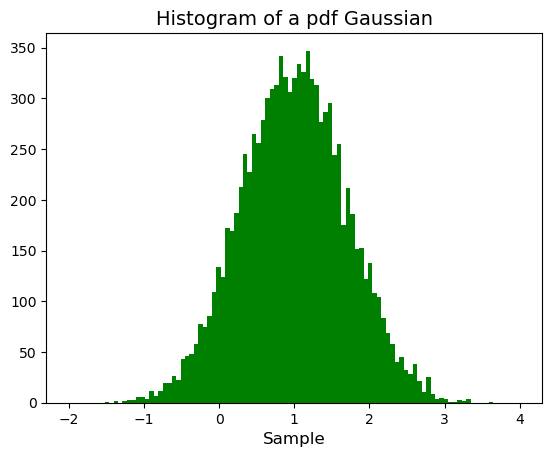

In [16]:
fig, ax = plt.subplots()
ax.hist( sample, bins = bin_edges, color = 'green')
ax.set_title('Histogram of a pdf Gaussian', size = 14)
ax.set_xlabel('Sample', size = 12)
plt.show()

In [17]:
#unbinned distribution
from scipy.stats import norm
def mod_signal_unb (x, mu, sigma) :
    return norm.pdf(x, mu, sigma)

In [18]:
from iminuit.cost import UnbinnedNLL
my_cost_func_unb = UnbinnedNLL ( sample, mod_signal_unb)
my_minuit_unb = Minuit( my_cost_func_unb, mu = np.mean(sample), sigma = np.std(sample))
my_minuit_unb.limits['sigma']= (0, None)                            #non metter mai la media positiva         

my_minuit_unb.migrad()                                                
print('The fit is : ', my_minuit_unb.valid)
display(my_minuit_unb)

The fit is :  True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.129e+04                  │              Nfcn = 22               │
│ EDM = 1.49e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │   0.996   │   0.007   │            │            │         │         │       │
│ 1 │ sigma │   0.701   │   0.005   │            │            │    0    │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │       mu    sigma │
├───────┼───────────────────┤
│    mu │ 4.92e-05        0 │
│ sigma │        0 2.46e-05 │
└───────┴───────────────────┘

In [27]:
#valori fittati di mu e sigma unbinned
mu_fit_unb = my_minuit_unb.values[0] 
sigma_fit_unb = my_minuit_unb.values[1]
err_mu_fit_unb = my_minuit_unb.errors[0]
err_sigma_fit_unb = my_minuit_unb.errors[1]
for par, val, err in zip( my_minuit_unb.parameters, my_minuit_unb.values, my_minuit_unb.errors) :
    print(f'{par} = {val} +- {err}')

mu = 0.9957549920674186 +- 0.007014364129352525
sigma = 0.7014363183004545 +- 0.004959892324413573


In [20]:
#binned distribution
def mod_total_bin (bin_edges, N_signal, mu, sigma):
    return N_signal * norm.cdf (bin_edges, mu, sigma)

In [21]:
my_cost_func_bin = ExtendedBinnedNLL ( bin_content, bin_edges, mod_total_bin)
my_minuit_bin = Minuit( my_cost_func_bin, N_signal = N_evt, mu = np.mean(sample), sigma = np.std(sample))
my_minuit_bin.limits['N_signal','sigma']= (0, None)

my_minuit_bin.migrad()                                                
print('The fit is : ', my_minuit_bin.valid)
display(my_minuit_bin)

The fit is :  True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 100.2 (χ²/ndof = 1.0)      │              Nfcn = 34               │
│ EDM = 9.13e-11 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N_signal │  10.0e3   │   0.1e3   │            │            │    0    │         │       │
│ 1 │ mu       │   0.996   │   0.007   │            │            │         │         │       │
│ 2 │ sigma    │   0.701   │   0.005   │            │            │    0    │         │       │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬────────────────────────────┐
│          │ N_signal       mu    sigma │
├──────────┼────────────────────────────┤
│ N_signal │    1e+04       -0 0.128e-3 │
│       mu │       -0 4.92e-05        0 │
│    sigma │ 0.128e-3        0 2.47e-05 │
└──────────┴────────────────────────────┘

In [26]:
#valori fittati di mu e sigma binned
N_fit = my_minuit_bin.values[0] 
mu_fit_bin = my_minuit_bin.values[1] 
sigma_fit_bin = my_minuit_bin.values[2]
err_mu_fit_bin = my_minuit_bin.errors[1]
err_sigma_fit_bin = my_minuit_bin.errors[2]
for par, val, err in zip( my_minuit_bin.parameters, my_minuit_bin.values, my_minuit_bin.errors) :
    print(f'{par} = {val} +- {err}')

N_signal = 10000.189555652432 +- 100.0018760353114
mu = 0.9957390426947662 +- 0.007016654233689415
sigma = 0.7013284978964297 +- 0.004970816268482281


In [23]:
#comparisation between binned and unbinned 
print('binned value of the mean : ' + str(mu_fit_bin) + ' +- ' + str(sigma_fit_bin) +
      '\nunbinned value of the mean : ' + str(mu_fit_unb) + ' +- ' + str(sigma_fit_unb))

binned value of the mean : 0.9957390426947662 +- 0.7013284978964297
unbinned value of the mean : 0.9957549920674186 +- 0.7014363183004545


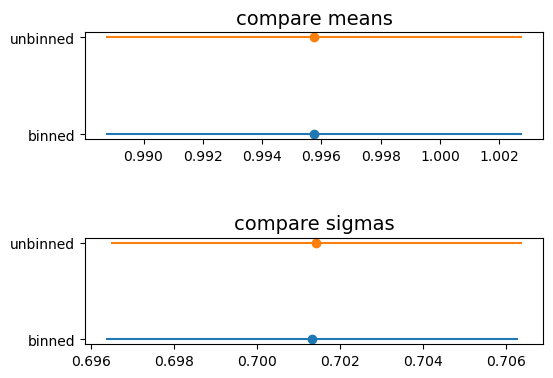

In [28]:
fig, axes = plt.subplots (2, 1)
# setting the two sub-figures apart
fig.tight_layout (pad=5.0)
# plot means
axes[0].set_title ('compare means', size=14)
axes[0].errorbar (mu_fit_bin, 'binned', xerr = err_mu_fit_bin, marker = 'o')
axes[0].errorbar (mu_fit_unb, 'unbinned', xerr = err_mu_fit_unb, marker = 'o')
#plot sigmas
axes[1].set_title ('compare sigmas', size=14)
axes[1].errorbar (sigma_fit_bin, 'binned', xerr = err_sigma_fit_bin, marker = 'o')
axes[1].errorbar (sigma_fit_unb, 'unbinned', xerr = err_sigma_fit_unb, marker = 'o')
plt.show ()

Exercise 12.3

Insert the source code of the previous exercise into a loop that performs the comparison as the number of events considered for the fit varies, from 20 to 10000, with a regular log-scale increment.
- Use different plots to show the behavior of the parameters and their uncertainties as the number of events changes, for both types of estimators.
- Add to the comparison the fit performed with the least squares method.
- Which estimator is less biased at low statistics?

In [30]:
from matplotlib import pyplot as plt
import numpy as np
from generator import generate_TCL_ms
from iminuit import Minuit
from scipy.stats import norm
from iminuit.cost import ExtendedBinnedNLL
from math import floor, ceil, sqrt

def sturge (N) :
    return floor (1 + 3.322 * np.log (N))

# for the binning choice
def mod_signal_bin (bin_edges, N_signal, mu, sigma):
            return N_signal * norm.cdf (bin_edges, mu, sigma)

sample_size = 20
N_toys = 50
N_evt = 10000
means_bin = []
sigmas_bin = []
events = []
while sample_size < N_evt :
    means_size = []
    sigmas_size = []
    for iToy in range (N_toys) :
        subsample = generate_TCL_ms (1., 0.7, sample_size)
        bin_content, bin_edges = np.histogram (subsample, bins = sturge (sample_size),range = (floor (min (subsample)), ceil (max (subsample))))
        
        my_cost_func_bin = ExtendedBinnedNLL (bin_content, bin_edges, mod_signal_bin)
        my_minuit_bin = Minuit (my_cost_func_bin, 
                                N_signal = sum (bin_content), 
                                mu = np.mean (subsample), 
                                sigma = np.std (subsample))
        my_minuit_bin.limits['N_signal', 'sigma'] = (0, None)
        my_minuit_bin.migrad ()
        if not my_minuit_bin.valid : continue
        means_size.append (my_minuit_bin.values[1])
        sigmas_size.append (my_minuit_bin.values[2])
    events.append (sample_size)
    means_bin.append ([np.mean (means_size), np.std (means_size)])
    sigmas_bin.append ([np.mean (sigmas_size), np.std (sigmas_size)])
    sample_size = sample_size * 2

In [31]:
# unbinned likelihood
from iminuit.cost import UnbinnedNLL

def mod_signal_unb (x, mu, sigma) :
    return norm.pdf(x, mu, sigma)

sample_size = 20
means_unb = []
sigmas_unb = []
while sample_size < N_evt :
    means_size = []
    sigmas_size = []
    for iToy in range (N_toys) :
        subsample = generate_TCL_ms (1., 0.7, sample_size)
        my_cost_func_unb = UnbinnedNLL (subsample, mod_signal_unb)
        my_minuit_unb = Minuit (
                                my_cost_func_unb, 
                                mu = np.mean (subsample), 
                                sigma = np.std (subsample),
                               )
        my_minuit_unb.limits["sigma"] = (0, None)
        my_minuit_unb.migrad ()
        if not my_minuit_unb.valid : continue
        means_size.append (my_minuit_unb.values[0])
        sigmas_size.append (my_minuit_unb.values[1])
    
    means_unb.append ([np.mean (means_size), np.std (means_size)])
    sigmas_unb.append ([np.mean (sigmas_size), np.std (sigmas_size)])
    sample_size = sample_size * 2

In [32]:
# least squares 
from iminuit.cost import LeastSquares

def sturges (N_events) :
    return ceil (1 + np.log2 (N_events))

def func_approx (x, N_events, mean, sigma, bin_width) :
    return N_events * norm.pdf (x, mean, sigma) * bin_width

sample_size = 20
means_ls = []
sigmas_ls = []
while sample_size < N_evt :
    means_size = []
    sigmas_size = []
    for iToy in range (N_toys) :
        subsample = generate_TCL_ms (1., 0.7, sample_size)
        bin_content, bin_edges = np.histogram (subsample, bins = sturges (sample_size), 
                                               range = (floor (min (subsample)), ceil (max (subsample))))
        bin_centres = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        sigma_y = [max (sqrt (num), 1.) for num in bin_content]

        least_squares = LeastSquares (bin_centres, bin_content, sigma_y, func_approx)
        my_minuit_ls = Minuit (least_squares,
                               N_events = sample_size,
                               mean = np.mean (subsample), 
                               sigma = np.std (subsample),
                               bin_width = bin_centres[1] - bin_centres[0]
                              )
        my_minuit_ls.fixed["bin_width", "N_events"] = True
        my_minuit_ls.migrad ()
        my_minuit_ls.hesse ()
        if not my_minuit_ls.valid : continue
        means_size.append (my_minuit_ls.values[1])
        sigmas_size.append (my_minuit_ls.values[2])

    means_ls.append ([np.mean (means_size), np.std (means_size)])
    sigmas_ls.append ([np.mean (sigmas_size), np.std (sigmas_size)])
    sample_size = sample_size * 2

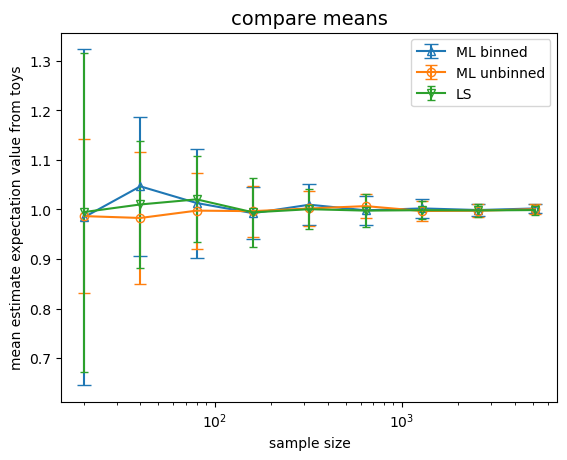

In [33]:
# compare the three fit
fig, ax = plt.subplots (1, 1)
ax.set_title ('compare means', size=14)
ax.set_xlabel ('sample size')
ax.set_ylabel ('mean estimate expectation value from toys')

means_bin_val, means_bin_err = map (list, zip (*means_bin))
ax.errorbar (events, means_bin_val, yerr = means_bin_err, marker = '^', markerfacecolor = 'none', label = 'ML binned', capsize = 5)

means_unb_val, means_unb_err = map (list, zip (*means_unb))
ax.errorbar (events, means_unb_val, yerr = means_unb_err, marker = 'o', markerfacecolor = 'none', label = 'ML unbinned', capsize = 4)

means_ls_val, means_ls_err = map (list, zip (*means_ls))
ax.errorbar (events, means_ls_val, yerr = means_ls_err, marker = 'v', markerfacecolor = 'none', label = 'LS', capsize = 3)

plt.xscale ("log")

ax.legend ()
plt.show ()